<a href="https://colab.research.google.com/github/elviraasch/UTS/blob/main/P6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **P6 A**

In [ ]:
import pandas as pd

df = pd.read_csv('HR-Employee-Attrition.csv')

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# **B**

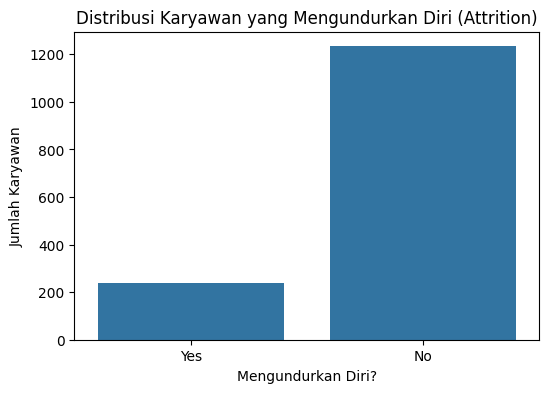

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Distribusi Karyawan yang Mengundurkan Diri (Attrition)')
plt.xlabel('Mengundurkan Diri?')
plt.ylabel('Jumlah Karyawan')
plt.show()

Grafik diatas nunjukan jumlah karyawan yang mengundurkan diri dibandingkan dengan yang tetap bekerja. Terlihat karyawan yang tidak mengundurkan diri jumlahnya jauh lebih banyak (1250 orang) dibandingkan dengan yang resign (250 orang). Artinya, tingkat resign memang ada, tetapi sebagian besar karyawan masih bertahan di perusahaan.

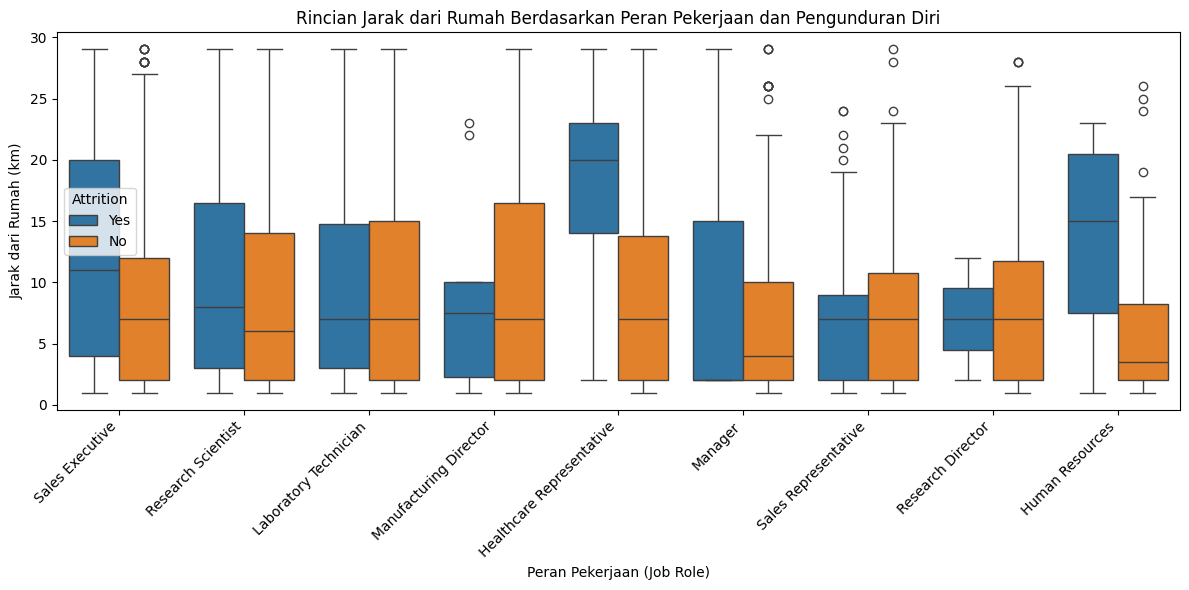

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='JobRole', y='DistanceFromHome', hue='Attrition')
plt.title('Rincian Jarak dari Rumah Berdasarkan Peran Pekerjaan dan Pengunduran Diri')
plt.xlabel('Peran Pekerjaan (Job Role)')
plt.ylabel('Jarak dari Rumah (km)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Grafik diatas nunjukin kalau karyawan yang resign biasanya tinggal lebih jauh dari kantor dibanding yang bertahan, terutama seperti Sales Executive dan Laboratory Technician. Sementara di posisi manajerial, jarak rumah relatif lebih dekat dan perbedaan antara yang resign dan tidak tidak terlalu besar.

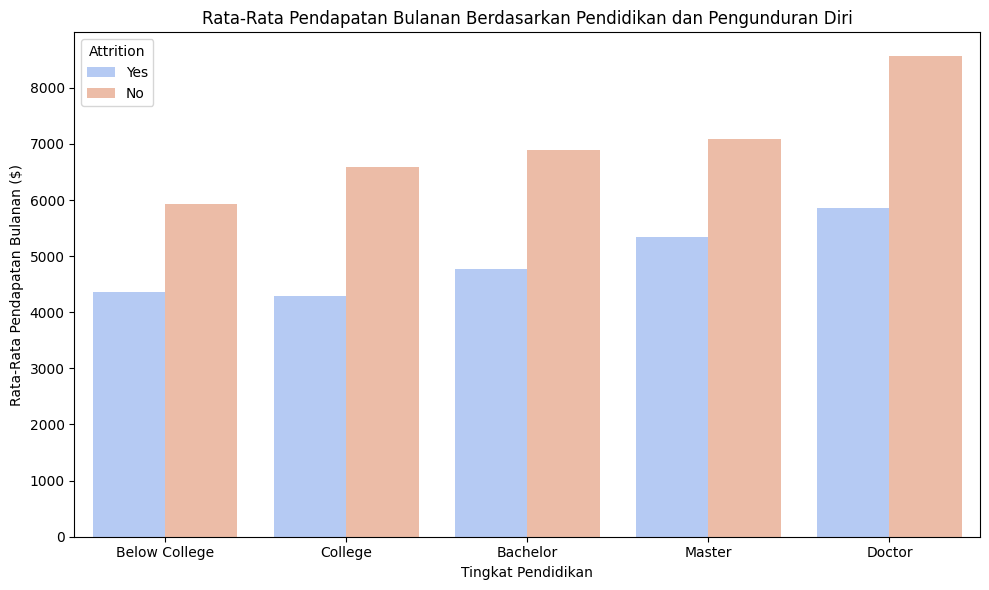

In [ ]:
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df_edu = df.copy()
df_edu['Education_Label'] = df_edu['Education'].map(edu_map)

plt.figure(figsize=(10, 6))

sns.barplot(data=df_edu, x='Education_Label', y='MonthlyIncome', hue='Attrition',
            estimator='mean', errorbar=None, palette='coolwarm',
            order=['Below College', 'College', 'Bachelor', 'Master', 'Doctor'])
plt.title('Rata-Rata Pendapatan Bulanan Berdasarkan Pendidikan dan Pengunduran Diri')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Rata-Rata Pendapatan Bulanan ($)')
plt.tight_layout()
plt.show()

Grafik diatas menunjukkan rata-rata pendapatan bulanan selalu lebih tinggi pada karyawan yang tidak mengundurkan diri dibandingkan dengan yang resign, di semua tingkat pendidikan. Selain itu, semakin tinggi tingkat pendidikan, rata-rata pendapatan juga meningkat. Artinya, pendapatan dan pendidikan berhubungan dengan karyawan berpendidikan lebih tinggi dengan gaji lebih besar cenderung bertahan lebih lama.

In [ ]:
from sklearn.preprocessing import LabelEncoder

kolom_tidak_berguna = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=[col for col in kolom_tidak_berguna if col in df.columns])

df_clean['Attrition'] = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)

kolom_kategorikal = df_clean.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_clean, columns=kolom_kategorikal, drop_first=True)

print("UKURAN DATA SETELAH ENCODING")
print(df_encoded.shape)

UKURAN DATA SETELAH ENCODING
(1470, 45)


# **C**

EVALUASI MODEL RANDOM FOREST
Akurasi: 83.33%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



/tmp/ipykernel_10950/3751314379.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_fitur, x='Tingkat_Kepentingan', y='Fitur', palette='viridis')


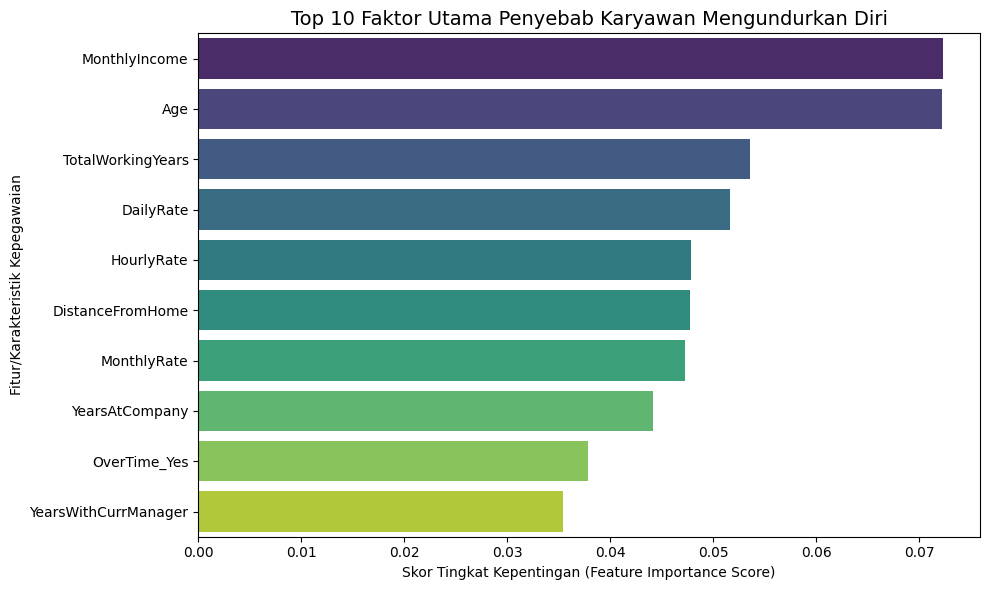

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Membuat dan Melatih Model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
print("EVALUASI MODEL RANDOM FOREST")
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

importances = model_rf.feature_importances_
fitur_imp_df = pd.DataFrame({'Fitur': X.columns, 'Tingkat_Kepentingan': importances})
top_10_fitur = fitur_imp_df.sort_values(by='Tingkat_Kepentingan', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_fitur, x='Tingkat_Kepentingan', y='Fitur', palette='viridis')
plt.title('Top 10 Faktor Utama Penyebab Karyawan Mengundurkan Diri', fontsize=14)
plt.xlabel('Skor Tingkat Kepentingan (Feature Importance Score)')
plt.ylabel('Fitur/Karakteristik Kepegawaian')
plt.tight_layout()
plt.show()

Grafik diatas nunjukin kalau faktor paling besar yang bikin karyawan resign adalah pendapatan bulanan, lalu usia dan total pengalaman kerja. Faktor lain seperti jarak rumah, lembur, dan lama kerja juga berpengaruh, tapi lebih kecil.